In [1]:
import os
import random
import time

import corner
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cmcrameri import cm

plt.rcParams["font.size"] = 16

# Compare grid to observations

In [2]:
T22 = pd.read_csv('../data/Tailo_2022_table_1.csv', dtype = {'GaiaeDR3 ID':str})[0:32]
M08a = pd.read_csv('../data/Marino_2008_abundances.txt')
M08c = pd.read_csv('../data/Marino_2008_classicals.txt')

T22_dr2dr3 = pd.read_csv('../data/Tailo_22_dr2_dr3_cross-result.csv', dtype = {'dr2_source_id':str, 'dr3_source_id':str}).rename({'dr3_source_id':'GaiaeDR3 ID', 'dr2_source_id':'Gaia DR2 ID'}, axis = 1)
M08 = pd.merge(M08a, M08c, on = 'Star')
T22b = pd.read_csv('../data/Tailo_2022_table_D1.csv').rename({'M1/M⊙':'M1', 'M2/M⊙':'M2', 'M4/M⊙':'M4', 'M3/M⊙':'M3'}, axis = 1)
T22b['M3'] = T22b['M3'].str.split('±', expand = True)[0].astype(float)
len(T22[T22['POPCUBI'] == '2G']), len(T22[T22['POPCUBI'] == '1G'])
H22 = pd.read_csv('../data/Howell_2022.txt')

T22 = pd.merge(T22, T22_dr2dr3[['Gaia DR2 ID', 'GaiaeDR3 ID']], on = 'GaiaeDR3 ID')

In [3]:
H22['numax'] = H22['νmax'].str.split('±', expand = True)[0].astype(float)
H22['dnu'] = H22['∆ν'].str.split('±', expand = True)[0].astype(float)
H22['teff'] = H22['Teff'].str.split('±', expand = True)[0].astype(float)
H22['e_numax'] = H22['νmax'].str.split('±', expand = True)[1].astype(float)
H22['e_teff'] =  H22['Teff'].str.split('±', expand = True)[1].astype(float)

In [39]:
T22[T22['Gaia DR2 ID'].isin(H22['Gaia DR2 ID'])]

,Unnamed: 0,WID,GaiaeDR3 ID,RA (J2000),Dec (J2000),Vdr (mag),CUBI (mag),Teff,lum,numax,dnu,POPSpec,POPCUBI,Gaia DR2 ID


In [64]:
H22

,ID,Gaia DR2 ID,Gmag,νmax,∆ν,QF,Teff,L/L⊙,R/R⊙,M3/M⊙,numax,dnu,teff
0,M4AGB01,6045466193429562880,12.08,9.7±0.9,1.49±0.08,MD,4944±29,104.1±0.9±12.1,23.8±3.2±3.2,0.56±0.05±0.07,9.7,1.49,4944.0
1,M4AGB02,6045466537026893696,11.84,6.7±0.4,1.39±0.05,D,4838±62,128.3±2.6±14.9,18.7±1.8±2.8,0.51±0.04±0.06,6.7,1.39,4838.0
2,M4AGB58,6045490107808665088,11.97,10.3±0.7,1.76±0.24,D,4840±108,122.3±4.1±14.2,17.8±4.2±2.7,0.75±0.08±0.09,10.3,1.76,4840.0
3,M4AGB59,6045489798570998144,11.36,4.9±0.2,1.16±0.11,MD,5029±108,209.0±5.5±24.3,19.8±3.4±2.4,0.53±0.05±0.06,4.9,1.16,5029.0
4,M4AGB62,6045484266652772864,11.93,8.1±0.2,1.40±0.03,D,4941±52,125.3±1.9±14.5,22.6±1.1±3.0,0.56±0.03±0.07,8.1,1.40,4941.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,M4RHB39,6045466296508676608,13.00,37.0±2.4,5.68±0.16,D,5358±108,42.7±0.7±5.0,6.5±0.6±0.4,0.66±0.06±0.08,37.0,5.68,5358.0
71,M4RHB41,6045477978820371712,13.04,36.3±1.4,4.97±0.28,D,5284±108,42.4±0.8±4.9,8.3±0.9±0.7,0.68±0.05±0.08,36.3,4.97,5284.0
72,M4RHB42,6045466433947664256,13.00,41.9±2.8,7.54±0.29,D,5545±108,40.7±0.6±4.7,4.3±0.4±0.2,0.64±0.06±0.07,41.9,7.54,5545.0
73,M4RHB44,6045478356777488256,13.03,40.8±2.9,6.08±0.36,D,5477±108,42.9±0.6±5.0,6.3±0.8±0.3,0.68±0.07±0.08,40.8,6.08,5477.0


In [34]:
H22

,ID,Gaia DR2 ID,Gmag,νmax,∆ν,QF,Teff,L/L⊙,R/R⊙,M3/M⊙
0,M4AGB01,6045466193429562880,12.08,9.7±0.9,1.49±0.08,MD,4944±29,104.1±0.9±12.1,23.8±3.2±3.2,0.56±0.05±0.07
1,M4AGB02,6045466537026893696,11.84,6.7±0.4,1.39±0.05,D,4838±62,128.3±2.6±14.9,18.7±1.8±2.8,0.51±0.04±0.06
2,M4AGB58,6045490107808665088,11.97,10.3±0.7,1.76±0.24,D,4840±108,122.3±4.1±14.2,17.8±4.2±2.7,0.75±0.08±0.09
3,M4AGB59,6045489798570998144,11.36,4.9±0.2,1.16±0.11,MD,5029±108,209.0±5.5±24.3,19.8±3.4±2.4,0.53±0.05±0.06
4,M4AGB62,6045484266652772864,11.93,8.1±0.2,1.40±0.03,D,4941±52,125.3±1.9±14.5,22.6±1.1±3.0,0.56±0.03±0.07
...,...,...,...,...,...,...,...,...,...,...
70,M4RHB39,6045466296508676608,13.00,37.0±2.4,5.68±0.16,D,5358±108,42.7±0.7±5.0,6.5±0.6±0.4,0.66±0.06±0.08
71,M4RHB41,6045477978820371712,13.04,36.3±1.4,4.97±0.28,D,5284±108,42.4±0.8±4.9,8.3±0.9±0.7,0.68±0.05±0.08
72,M4RHB42,6045466433947664256,13.00,41.9±2.8,7.54±0.29,D,5545±108,40.7±0.6±4.7,4.3±0.4±0.2,0.64±0.06±0.07
73,M4RHB44,6045478356777488256,13.03,40.8±2.9,6.08±0.36,D,5477±108,42.9±0.6±5.0,6.3±0.8±0.3,0.68±0.07±0.08


In [6]:
SUNnumax = 3090
gridname = "chiara"
gridpath = "../grids/Garstec_AS09_chiara.hdf5"


headers = [
    "massini",
    "zini",
    "yini",
    "alphaMLT",
    "age",
    "TAMS",
    "radPhot",
    "LPhot",
    "Teff",
    "zsur",
    "numax",
    "dnufit",
]

nmin = 1
nmax = 15

grid = h5py.File(gridpath, "r")

def track_df_gen(
    grid: h5py.File,
    track_ids: list[str, ...],
    headers: list[str, str, str] = ["age", "Teff", "LPhot"],
):
    i = 0
    for track_id in track_ids:
        track = grid["grid/tracks/track" + track_id]

        track_array = np.full(len(track[headers[0]]), int(track_id))

        for header in headers:
            track_array = np.column_stack((track_array, np.array(track[header])))

        if i == 0:
            tracks_array = track_array
            i = 1
        else:
            tracks_array = np.vstack((tracks_array, track_array))

    return pd.DataFrame(tracks_array, columns=["track_id"] + headers)

In [66]:
def plot_hroverview(
    grid: h5py.File,
    headers: list[str, str, str, str] = ["age", "Teff", "LPhot", "TAMS", "numax", "FeHini", "eta", "massini"],
    nosamples: int = 100,
    withincurrentuniverse: bool = False,
    seed: int = 42,
):
    random.seed(seed)
    track_ids = [
        track_name.replace("track", "")
        for track_name in random.sample(list(grid["grid/tracks"]), nosamples)
    ]

    tracks_df = track_df_gen(grid, track_ids, headers)

    if withincurrentuniverse:
        mask = (tracks_df["age"] <= 14e3) & (tracks_df["TAMS"] >= 0)
        tracks_df = tracks_df[mask]

    fighr = plt.figure(figsize=(10, 10))
    plt.scatter(
        (tracks_df[headers[1]]),
        (tracks_df[headers[4]])*SUNnumax,
        c=tracks_df[headers[0]] / 1000,
        cmap=cm.buda,
    )
    plt.ylabel(r'$\nu_{\mathrm{max}}$ [$\mu$Hz]')
    plt.xlabel(r'$T_{\mathrm{eff}}$ [K]')
    
    cbar = plt.colorbar()
    cbar.set_label(f"{headers[0]}")
#    plt.scatter(T22['Teff'].astype(float), T22['numax'].str.split(' ', expand = True)[0].astype(float), facecolor = 'white', edgecolor = 'black', label = 'Tailo 2022', s = 100)
    plt.errorbar(H22['teff'], H22['numax'], fmt = 'o', markerfacecolor = 'lightpink', markeredgecolor = 'black', label = 'Howell 2022', color = 'black', capsize = 5, yerr = H22['e_numax'], xerr=H22['e_teff'])
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.semilogy()
    plt.legend()
    fighr.savefig('../figs/chiara_tailo_22.png', bbox_inches = 'tight')

    figfeh = plt.figure(figsize=(5, 3))
    binwidth = 0.1
  
    plt.hist(tracks_df[headers[5]], density = True, histtype = 'step', fill = True, color = 'black',\
             bins = int(np.max((tracks_df[headers[5]]) - np.min(tracks_df[headers[5]])/binwidth)), label = 'grid')
    plt.hist(M08['[Fe/HI]'], density = True, fill = True, edgecolor = 'magenta', color = 'white',\
              histtype = 'step', bins = int(np.max((M08['[Fe/HI]']) - np.min(M08['[Fe/HI]'])/binwidth)), label = 'Marino 08')
    plt.legend()
    plt.xlabel('[Fe/H] [dex]')
    plt.ylabel('Density')
    figfeh.savefig('../figs/chiara_feh.png', bbox_inches = 'tight')

    figeta = plt.figure(figsize=(5, 3))
    binwidth = 0.1
  
    plt.hist(tracks_df[headers[6]], density = True, histtype = 'step', fill = True, color = 'black',\
             bins = 10, label = 'grid')
    plt.xlabel(r'$\eta$')
    plt.ylabel('Density')
    plt.gca().axvspan(0.3, 0.4, color = 'magenta', alpha = 0.3)
    figeta.savefig('../figs/chiara_eta.png', bbox_inches = 'tight')


    figmass = plt.figure(figsize=(7, 5))
    binwidth = 0.03
    
    plt.hist(tracks_df[headers[7]], density = True, histtype = 'step', fill = True, color = 'black',\
             bins = int((np.nanmax(tracks_df[headers[7]]) - np.nanmin(tracks_df[headers[7]]))/binwidth), label = 'grid initial mass')
    plt.hist(T22b['M3'], density = True, fill = True, edgecolor = 'magenta', color = 'white',\
              histtype = 'step', bins = int((np.max(T22b['M3']) - np.min(T22b['M3']))/binwidth), label = 'Tailo 22 current mass')
    plt.legend()
    plt.xlabel(r'Mass [M$_{\odot}$]')
    plt.ylabel('Density')
    figmass.savefig('../figs/chiara_mass.png', bbox_inches = 'tight')




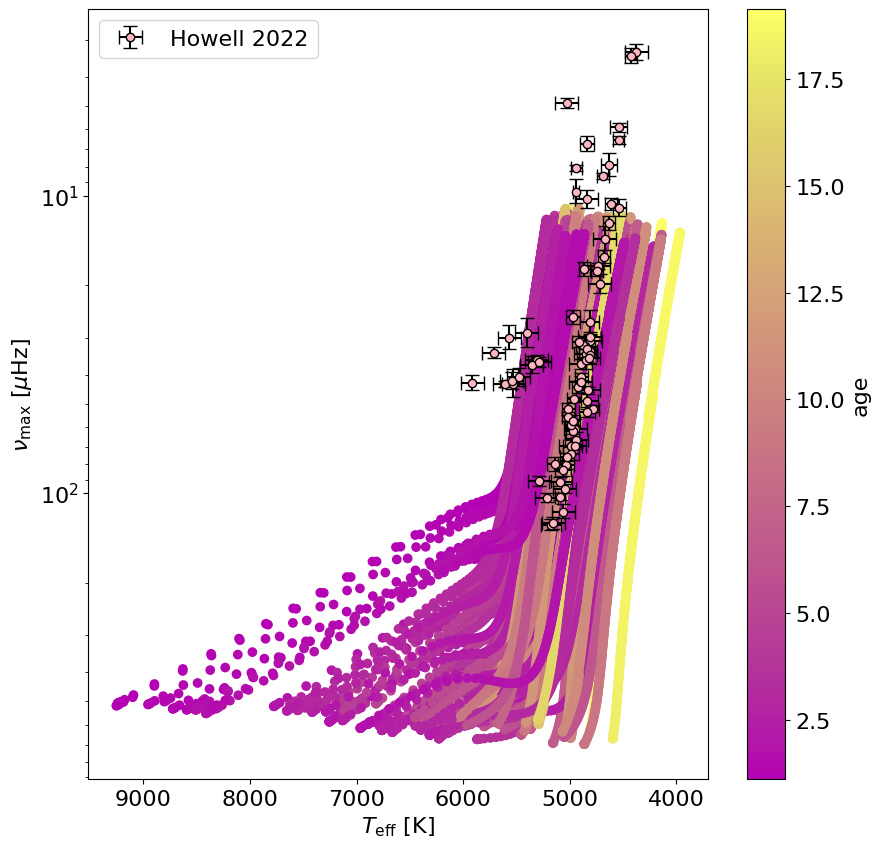

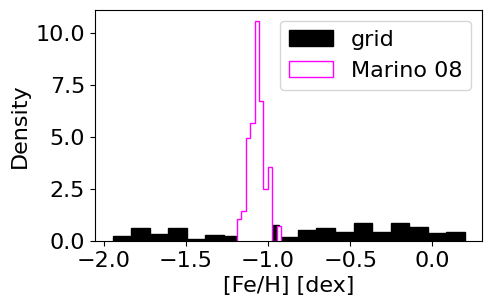

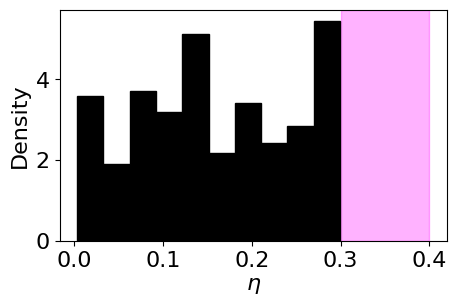

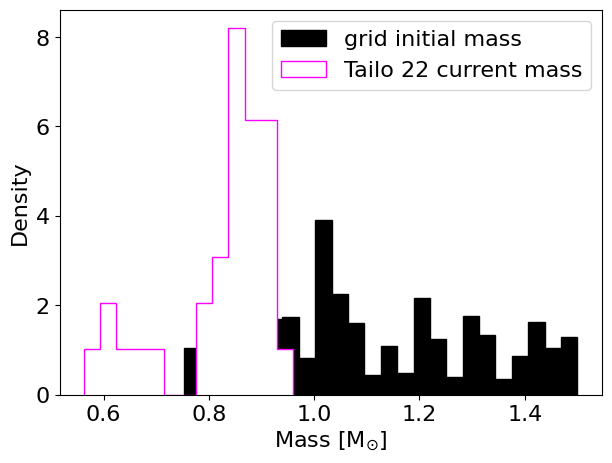

In [67]:
plot_hroverview(grid)

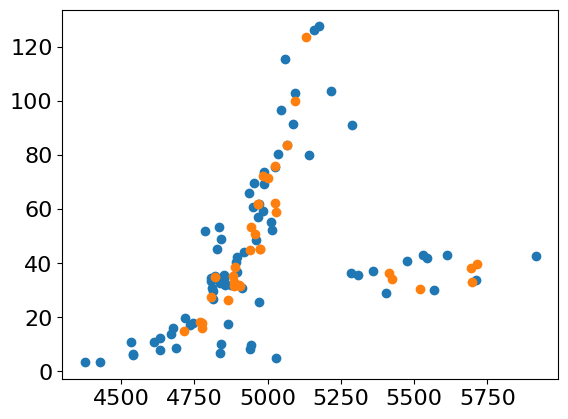

In [50]:
plt.scatter(H22['teff'], H22['numax'])
plt.scatter(T22['Teff'].astype(float) +100, T22['numax'].str.split(' ', expand = True)[0].astype(float))

In [61]:
for i in T22.index:
    t22teff = float(T22.loc[i, 'Teff'])
    t22numax = float(T22.loc[i, 'numax'].split(' ')[0])

    distances = np.sqrt((H22['numax'].values - t22numax)**2+(H22['teff'].values - t22teff)**2)

    radius = np.sqrt(float(T22.loc[i, 'numax'].split(' ')[2])**2 + 112**2)
    print(f'min distance = {np.min(distances)}, err radius = {radius}, min numax diff = {np.min(np.abs(H22['numax'].values - t22numax))}, min numax err = {np.min(float(T22.loc[i, 'numax'].split(' ')[2]))}')

min distance = 13.610737525938852, err radius = 112.00415717731195, min numax diff = 1.7239999999999966, min numax err = 0.965
min distance = 14.751584355587035, err radius = 112.02500921222904, min numax diff = 0.5289999999999964, min numax err = 2.367
min distance = 5.762456420659508, err radius = 112.0046810450349, min numax diff = 0.2480000000000011, min numax err = 1.024
min distance = 5.940510415780788, err radius = 112.02275913402597, min numax diff = 0.007999999999995566, min numax err = 2.258
min distance = 18.75855175646564, err radius = 112.0152944958857, min numax diff = 0.19200000000000017, min numax err = 1.851
min distance = 30.21440715949926, err radius = 112.05583594351523, min numax diff = 2.319999999999993, min numax err = 3.537
min distance = 29.38553766736284, err radius = 112.03597601217209, min numax diff = 1.9679999999999893, min numax err = 2.839
min distance = 20.08985823742915, err radius = 112.01323709276507, min numax diff = 0.402000000000001, min numax err

In [56]:
T22['numax'].str.split(' ', expand = True)[2]

0     0.965
1     2.367
2     1.024
3     2.258
4     1.851
5     3.537
6     2.839
7     1.722
8     0.995
9     1.907
10    2.312
11    2.277
12    1.718
13    1.461
14    2.931
15    1.422
16    1.047
17    1.714
18    1.784
19    0.726
20    0.445
21    0.878
22    2.520
23    1.396
24    2.156
25    1.000
26    1.000
27    1.775
28    1.775
29    3.100
30    2.938
31    1.680
32    1.957
33    1.425
Name: 2, dtype: object